<a href="https://colab.research.google.com/github/sanskriti-iyer/Music-and-Mental-Health/blob/main/SmartVizMed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ========== 1. INSTALL DEPENDENCIES ==========
!pip install numpy==1.23.5 --quiet

In [ ]:
# ========== 2. IMPORT LIBRARIES ==========
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
import sweetviz as sv
import numpy as np
from pandas.api.types import is_numeric_dtype, is_categorical_dtype

print("SweetViz Version : {}".format(sv.__version__))

SweetViz Version : 2.3.1


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/SmartVizMed/data/mxmh_survey_results.csv')

In [ ]:
df.head()

,UniqueID,Age,Hours per day,While working,Instrumentalist,Composer,Exploratory,Foreign languages,BPM,Anxiety,...,Frequency [Rap]_Very frequently,Frequency [Rock]_Rarely,Frequency [Rock]_Sometimes,Frequency [Rock]_Very frequently,Frequency [Video game music]_Rarely,Frequency [Video game music]_Sometimes,Frequency [Video game music]_Very frequently,Music effects_Improve,Music effects_Worsen,Cluster
0,1,18.0,3.0,1.0,1.0,1.0,1,1.0,156.0,3.0,...,True,False,False,False,False,True,False,True,False,2
1,2,63.0,1.5,1.0,0.0,0.0,1,0.0,119.0,7.0,...,False,False,False,True,True,False,False,True,False,1
2,3,18.0,4.0,0.0,0.0,0.0,0,1.0,132.0,7.0,...,False,True,False,False,False,False,True,False,False,0
3,4,61.0,2.5,1.0,0.0,1.0,1,1.0,84.0,9.0,...,False,False,False,False,False,False,False,True,False,1
4,5,18.0,4.0,1.0,0.0,0.0,1,0.0,107.0,7.0,...,True,False,False,False,True,False,False,True,False,2


In [ ]:
# ========== 4. DATA CLEANING ==========
def clean_dataframe(df):
    for col in df.columns:
        if df[col].dtype in ['float64', 'int64']:
            df[col].fillna(df[col].median(), inplace=True)
        elif df[col].dtype == 'object':
            df[col].fillna(df[col].mode()[0], inplace=True)
    return df

df = clean_dataframe(df)

/tmp/ipython-input-803978852.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipython-input-803978852.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

In [ ]:
# ===== 3. CLEAN + PREPROCESS =====
# Fill missing values automatically
for col in df.columns:
    if is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].median())
    elif is_categorical_dtype(df[col]) or df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])

# Encode categoricals
df = pd.get_dummies(df, drop_first=True)

/tmp/ipython-input-861171776.py:6: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif is_categorical_dtype(df[col]) or df[col].dtype == 'object':


In [ ]:
# ========== 5. ENCODE CATEGORICAL ==========
le = LabelEncoder()
for col in df.select_dtypes(include='object'):
    df[col] = le.fit_transform(df[col])

In [ ]:
# ========== 6. SCALE FOR ANALYSIS ==========
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

In [ ]:
print(df.columns.tolist())

['UniqueID', 'Age', 'Hours per day', 'While working', 'Instrumentalist', 'Composer', 'Exploratory', 'Foreign languages', 'BPM', 'Anxiety', 'Depression', 'Insomnia', 'OCD', 'Primary streaming service_I dont use a streaming service.', 'Primary streaming service_Other streaming service', 'Primary streaming service_Pandora', 'Primary streaming service_Spotify', 'Primary streaming service_YouTube Music', 'Fav genre_Country', 'Fav genre_EDM', 'Fav genre_Folk', 'Fav genre_Gospel', 'Fav genre_Hip hop', 'Fav genre_Jazz', 'Fav genre_K pop', 'Fav genre_Latin', 'Fav genre_Lofi', 'Fav genre_Metal', 'Fav genre_Pop', 'Fav genre_R&B', 'Fav genre_Rap', 'Fav genre_Rock', 'Fav genre_Video game music', 'Frequency [Classical]_Rarely', 'Frequency [Classical]_Sometimes', 'Frequency [Classical]_Very frequently', 'Frequency [Country]_Rarely', 'Frequency [Country]_Sometimes', 'Frequency [Country]_Very frequently', 'Frequency [EDM]_Rarely', 'Frequency [EDM]_Sometimes', 'Frequency [EDM]_Very frequently', 'Frequen

In [ ]:
import pandas as pd
# Define cluster labels based on your understanding
cluster_names = {
    0: '0: High Anxiety/Depression',
    1: '1: Low Symptoms',
    2: '2: Severe Symptoms'
}

df['Cluster_Label'] = df['Cluster'].map(cluster_names)

# Show some summary stats by cluster label
summary = df.groupby('Cluster_Label')[['Anxiety', 'Depression', 'OCD', 'Insomnia']].mean()
print("\nCluster Profiles:")
print(summary)
# Assuming your clusters are in df['Cluster']

# Example: Check average 'Depression' by cluster and 'Music effects'
music_effects_by_cluster = df.groupby(['Cluster', 'Music effects_Improve','Music effects_Worsen'])['Depression'].mean().unstack()
print("Average Depression by Cluster and Music Effects:")
print(music_effects_by_cluster)

# If you have genre frequency columns (like 'Frequency [Rock]', 'Frequency [Hip hop]')
genre_cols = [col for col in df.columns if col.startswith('Frequency')]
genre_means_by_cluster = df.groupby('Cluster')[genre_cols].mean()
print("\nAverage Genre Frequencies by Cluster:")
print(genre_means_by_cluster)



Cluster Profiles:
                             Anxiety  Depression       OCD  Insomnia
Cluster_Label                                                       
0: High Anxiety/Depression  7.327801    5.665975  2.309129  1.935685
1: Low Symptoms             2.806584    1.962963  1.316872  2.069959
2: Severe Symptoms          7.335317    6.696429  4.224206  7.071429
Average Depression by Cluster and Music Effects:
Music effects_Worsen              False  True 
Cluster Music effects_Improve                 
0       False                  5.773585    6.2
        True                   5.620219    NaN
1       False                  1.681159    3.0
        True                   2.063953    NaN
2       False                  6.765957    8.5
        True                   6.587179    NaN

Average Genre Frequencies by Cluster:
         Frequency [Classical]_Rarely  Frequency [Classical]_Sometimes  \
Cluster                                                                  
0                       


Cluster Profiles:
                          Anxiety  Depression       OCD  Insomnia
Cluster_Label                                                    
High Anxiety/Depression  7.327801    5.665975  2.309129  1.935685
Low Symptoms             2.806584    1.962963  1.316872  2.069959
Severe Symptoms          7.335317    6.696429  4.224206  7.071429


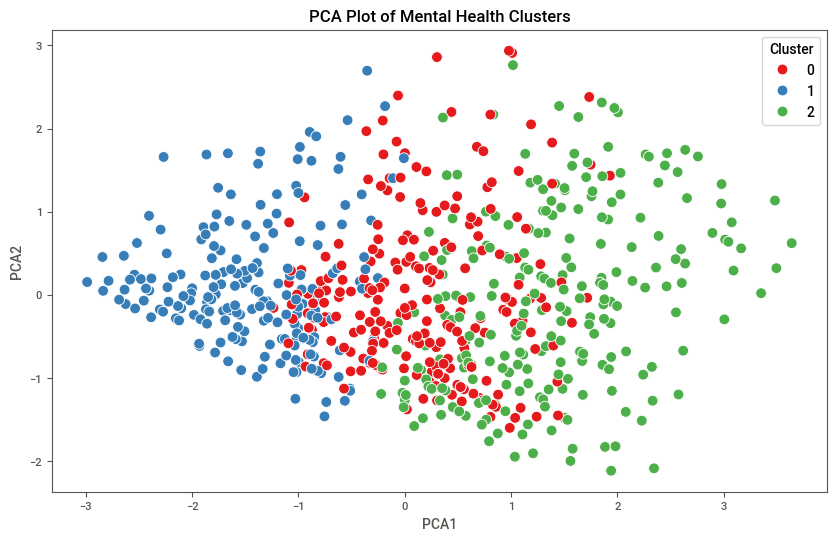

/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


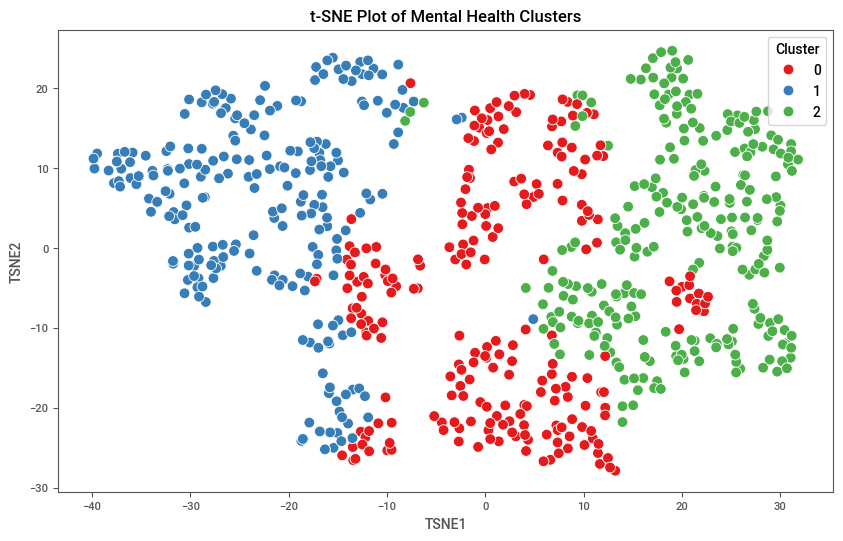

In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# Use scaled data from your clustering step: scaled_data (shape: n_samples x n_features)

# PCA plot
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)
df['PCA1'] = pca_result[:,0]
df['PCA2'] = pca_result[:,1]

plt.figure(figsize=(10,6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=df, palette='Set1', s=60)
plt.title('PCA Plot of Mental Health Clusters')
plt.show()

# t-SNE plot (alternative)
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
tsne_result = tsne.fit_transform(scaled_data)
df['TSNE1'] = tsne_result[:,0]
df['TSNE2'] = tsne_result[:,1]

plt.figure(figsize=(10,6))
sns.scatterplot(x='TSNE1', y='TSNE2', hue='Cluster', data=df, palette='Set1', s=60)
plt.title('t-SNE Plot of Mental Health Clusters')
plt.show()

In [ ]:
# Generate Sweetviz report
report = sv.analyze(df)

# Show report in an HTML file
report.show_html('sweetviz_report.html')

                                             |          | [  0%]   00:00 -> (? left)

Report sweetviz_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [ ]:
from google.colab import files
files.download('sweetviz_report.html')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>